In [1]:
import sys

!{sys.executable} -m pip install tensorflow

try:
    from mtcnn import MTCNN
   
    detector = MTCNN()
    
except ImportError as e:
    print(f"Ошибка: {e}")

MTCNN успешно установлен!
Детектор MTCNN инициализирован


In [2]:
import zipfile
import pandas as pd
import os
from pathlib import Path

test_dir = Path('celeba_test')
test_dir.mkdir(exist_ok=True)

archive_path = 'arch.zip'

files_to_extract = [
    'list_bbox_celeba.csv',
    'list_landmarks_align_celeba.csv', 
    'list_attr_celeba.csv',
    'list_eval_partition.csv'
]

with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    #распаковываем все CSV файлы
    for file in files_to_extract:
        try:
            zip_ref.extract(file, test_dir)
            print(f"Распакован: {file}")
        except KeyError:
            print(f"Файл не найден: {file}")

Распакован: list_bbox_celeba.csv
Распакован: list_landmarks_align_celeba.csv
Распакован: list_attr_celeba.csv
Распакован: list_eval_partition.csv


In [3]:
import zipfile
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os


num_of_images=100
with zipfile.ZipFile('arch.zip', 'r') as zip_ref:
    all_files = zip_ref.namelist()
    selected = [f for f in all_files if f.endswith('.jpg')][:num_of_images]
    
    images = []
    names = []
    
    for img_path in selected:
        with zip_ref.open(img_path) as file:
            img_data = np.frombuffer(file.read(), np.uint8)
            img = cv2.cvtColor(cv2.imdecode(img_data, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
            images.append(img)
            names.append(os.path.basename(img_path))

def show_img(idx):
    if 0 <= idx < len(images):
        plt.figure(figsize=(8, 6))
        plt.imshow(images[idx])
        plt.title(f"{idx}: {names[idx]}")
        plt.axis('off')
        plt.show()
    else:
        print(f" {idx} вне диапазона (0-{len(images)-1})")

print(f"Загружено {len(images)} фото: {names}")

Загружено 100 фото: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg', '000007.jpg', '000008.jpg', '000009.jpg', '000010.jpg', '000011.jpg', '000012.jpg', '000013.jpg', '000014.jpg', '000015.jpg', '000016.jpg', '000017.jpg', '000018.jpg', '000019.jpg', '000020.jpg', '000021.jpg', '000022.jpg', '000023.jpg', '000024.jpg', '000025.jpg', '000026.jpg', '000027.jpg', '000028.jpg', '000029.jpg', '000030.jpg', '000031.jpg', '000032.jpg', '000033.jpg', '000034.jpg', '000035.jpg', '000036.jpg', '000037.jpg', '000038.jpg', '000039.jpg', '000040.jpg', '000041.jpg', '000042.jpg', '000043.jpg', '000044.jpg', '000045.jpg', '000046.jpg', '000047.jpg', '000048.jpg', '000049.jpg', '000050.jpg', '000051.jpg', '000052.jpg', '000053.jpg', '000054.jpg', '000055.jpg', '000056.jpg', '000057.jpg', '000058.jpg', '000059.jpg', '000060.jpg', '000061.jpg', '000062.jpg', '000063.jpg', '000064.jpg', '000065.jpg', '000066.jpg', '000067.jpg', '000068.jpg', '000069.jpg', '000070.jpg',

 Название файла: 000089.jpg

 Время обработки: 958.35 мс
 Найдено лиц: 1
 Лиц с уверенностью >0.7: 1

 Лицо 1: уверенность 0.986
   Координаты: x=49, y=71, w=85, h=107


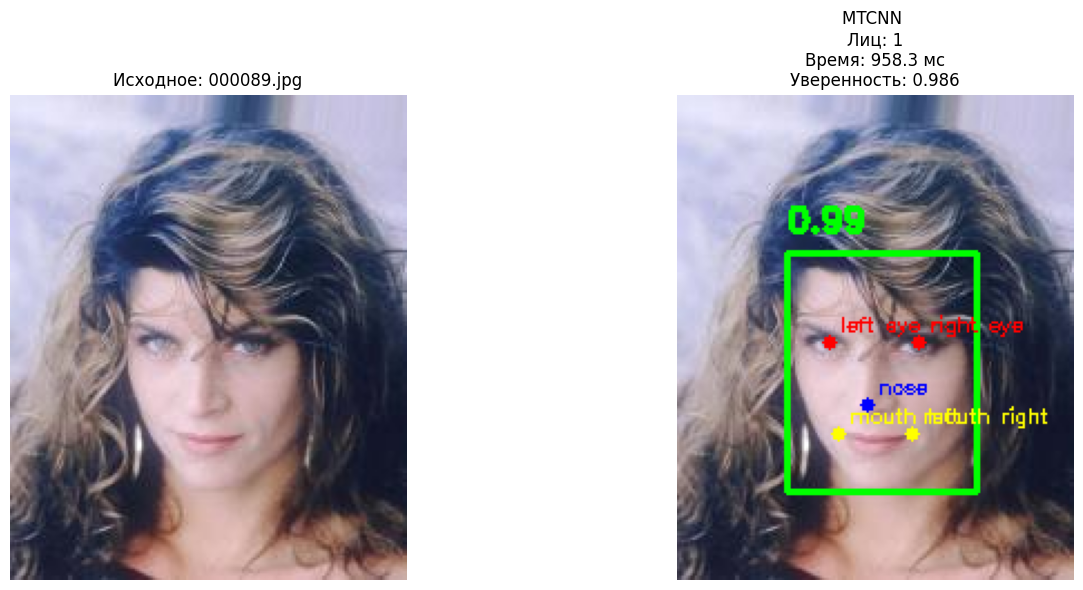


 Детальная статистика:
  - Время обработки: 958.35 мс
  - Лицо 1: уверенность 0.986


In [4]:
from mtcnn import MTCNN
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

#инициализация MTCNN
detector = MTCNN()

def test_mtcnn_on_image(image, image_name):
    annotated_image = image.copy()
    
    start_time = time.time()
    results = detector.detect_faces(image)
    inference_time = (time.time() - start_time) * 1000
    
    print(f"\n Время обработки: {inference_time:.2f} мс")
    
    if not results:
        print(" Лица не обнаружены")
        return None, None, None
    
    print(f" Найдено лиц: {len(results)}")
    
    h, w, _ = image.shape
    
    #фильтруем с уверенностью > 0.7
    filtered_results = [r for r in results if r['confidence'] > 0.7]
    print(f" Лиц с уверенностью >0.7: {len(filtered_results)}")
    
    for i, result in enumerate(filtered_results):
        confidence = result['confidence']
        bbox = result['box']
        keypoints = result['keypoints']
        
        x, y, width, height = bbox
        print(f"\n Лицо {i+1}: уверенность {confidence:.3f}")
        print(f"   Координаты: x={x}, y={y}, w={width}, h={height}")
        
        
        cv2.rectangle(annotated_image, (x, y), (x + width, y + height), (0, 255, 0), 2)
        cv2.putText(annotated_image, f"{confidence:.2f}", (x, y-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        keypoint_names = ['left_eye', 'right_eye', 'nose', 'mouth_left', 'mouth_right']
        colors = [(255,0,0), (255,0,0), (0,0,255), (255,255,0), (255,255,0)]
        
        for j, (name, color) in enumerate(zip(keypoint_names, colors)):
            if name in keypoints:
                point = keypoints[name]
                cv2.circle(annotated_image, point, 3, color, -1)
                cv2.putText(annotated_image, name.replace('_', ' '), (point[0]+5, point[1]-5), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1)
    
    stats = {
        'num_faces': len(filtered_results),
        'inference_time_ms': inference_time,
        'confidences': [r['confidence'] for r in filtered_results],
        'boxes': [r['box'] for r in filtered_results],
        'keypoints': [r['keypoints'] for r in filtered_results]
    }
    
    return annotated_image, stats, filtered_results

#тестируем
img = images[88]
img_name = names[88]

print(f" Название файла: {img_name}")

result_img, stats, results = test_mtcnn_on_image(img, img_name)

if result_img is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    axes[0].imshow(img)
    axes[0].set_title(f"Исходное: {img_name}")
    axes[0].axis('off')
    
    axes[1].imshow(result_img)
    conf_str = ', '.join([f'{c:.3f}' for c in stats['confidences']])
    axes[1].set_title(f"MTCNN \nЛиц: {stats['num_faces']}\nВремя: {stats['inference_time_ms']:.1f} мс\nУверенность: {conf_str}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n Детальная статистика:")
    print(f"  - Время обработки: {stats['inference_time_ms']:.2f} мс")
    for i, conf in enumerate(stats['confidences']):
        print(f"  - Лицо {i+1}: уверенность {conf:.3f}")

In [5]:
from mtcnn import MTCNN
import cv2
import numpy as np
import pandas as pd

gt_df = pd.read_csv('celeba_test/list_landmarks_align_celeba.csv')

#инициализация MTCNN
detector = MTCNN()

RADIUS = 10

total_tp = total_fp = total_fn = 0

for img, img_name in zip(images, names):
    gt = gt_df[gt_df['image_id'] == img_name].iloc[0]
    gt_points = [
        (gt['lefteye_x'], gt['lefteye_y']),
        (gt['righteye_x'], gt['righteye_y']),
        (gt['nose_x'], gt['nose_y'])
    ]
    
    results = detector.detect_faces(img)
    
    if not results:
        total_fn += 3
        continue
    
    h, w, _ = img.shape
    
    tp = fp = 0
    found_gt = [False] * 3
    
    #собираем все предсказанные точки (глаза, нос)
    for result in results:
        keypoints = result['keypoints']
        
        #берем только левый глаз, правый глаз, нос
        pred_points = [
            keypoints['left_eye'],
            keypoints['right_eye'],
            keypoints['nose']
        ]
        
        for pred in pred_points:
            matched = False
            for i, gt_pt in enumerate(gt_points):
                if not found_gt[i]:
                    dist = np.sqrt((pred[0]-gt_pt[0])**2 + (pred[1]-gt_pt[1])**2)
                    if dist <= RADIUS:
                        tp += 1
                        found_gt[i] = True
                        matched = True
                        break
            if not matched:
                fp += 1
    
    fn = found_gt.count(False)
    
    total_tp += tp
    total_fp += fp
    total_fn += fn

p = total_tp/(total_tp+total_fp) if total_tp+total_fp else 0
r = total_tp/(total_tp+total_fn) if total_tp+total_fn else 0
f1 = 2*p*r/(p+r) if p+r else 0

print(f"Всего изображений: {len(images)}")
print(f"TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")
print(f"Precision: {p:.3f}")
print(f"Recall: {r:.3f}")
print(f"F1-score: {f1:.3f}")

Всего изображений: 100
TP: 299, FP: 1, FN: 1
Precision: 0.997
Recall: 0.997
F1-score: 0.997
